# Forrester `sigma_eps2` Recovery Diagnostics

This notebook isolates measurement-noise recovery on the Forrester example. The baseline path is the dense slow solver with a fixed `Psi = I`, so `sigma_eps2` is not confounded by the SVD-based fast parameterization.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

sys.path.append(os.path.abspath(".."))

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

from moogp.forrester_illustration import (
    FORRESTER_MANUSCRIPT_SIGMA_EPS2,
)

from moogp.tests.test_forrester_sigma_eps_diagnostics import (
    run_forrester_sigma_eps_study,
    summarize_forrester_sigma_eps_study   
)

The manuscript example uses true noise variances `diag(10, 1, 0.05)`.

In [15]:
def show_rows(rows):
    if pd is not None:
        return pd.DataFrame(rows)
    return rows


def apply_n_axis_scaling(ax, n_values):
    n_values = sorted(n_values)
    if len(n_values) >= 2 and (max(n_values) / min(n_values)) >= 8:
        ax.set_xscale("log")
    ax.set_xticks(n_values)
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.set_xlim(min(n_values) * 0.9, max(n_values) * 1.1)


manuscript_sigma_eps2 = FORRESTER_MANUSCRIPT_SIGMA_EPS2.copy()
diagnostic_sigma_eps2 = np.array([10.0, 1.0, 0.05])

# Keep the dense slow baseline on modest N values; it gets expensive quickly.
slow_sample_sizes = [25, 50, 100, 250, 500]
fast_sample_sizes_to_run = [25, 50, 100, 250, 500]
seeds = [67, 123, 321]


In [16]:
slow_cases = run_forrester_sigma_eps_study(
    sample_sizes=slow_sample_sizes,
    seeds=seeds,
    true_sigma_eps2=diagnostic_sigma_eps2,
    Psi=np.eye(3),
    use_fast=False,
    maxiter=300,
)
slow_summary = summarize_forrester_sigma_eps_study(slow_cases)
show_rows(slow_summary)


,n_train,output,true_sigma_eps2,mean_sigma_eps2_hat,std_sigma_eps2_hat,rmse_sigma_eps2_hat,used_fast
0,25,1,10.00,5.681040,1.879533,4.710208,False
1,25,2,1.00,0.466506,0.137297,0.550878,False
2,25,3,0.05,0.040748,0.006994,0.011598,False
3,50,1,10.00,6.536849,0.280107,3.474461,False
4,50,2,1.00,0.870845,0.174010,0.216704,False
5,50,3,0.05,0.052961,0.006412,0.007063,False
6,100,1,10.00,8.421692,0.239237,1.596337,False
7,100,2,1.00,0.993561,0.114568,0.114749,False
8,100,3,0.05,0.047244,0.001490,0.003133,False
9,250,1,10.00,9.442031,0.429644,0.704219,False


In [17]:
assert all(not case["used_fast"] for case in slow_cases)
assert all(case["model"].cache["fast_diag_info"] is None for case in slow_cases)
assert all(np.allclose(case["Psi_hat"], np.eye(3)) for case in slow_cases)

case_50_seed67 = next(case for case in slow_cases if case["n_train"] == 50 and case["seed"] == 67)
case_100_seed67 = next(case for case in slow_cases if case["n_train"] == 100 and case["seed"] == 67)

assert abs(case_50_seed67["sigma_eps2_hat"][2] - diagnostic_sigma_eps2[2]) < 0.02
assert abs(case_100_seed67["sigma_eps2_hat"][2] - diagnostic_sigma_eps2[2]) < 0.01

case_50_seed67["sigma_eps2_hat"]


array([6.49323752, 1.00980128, 0.04425556])

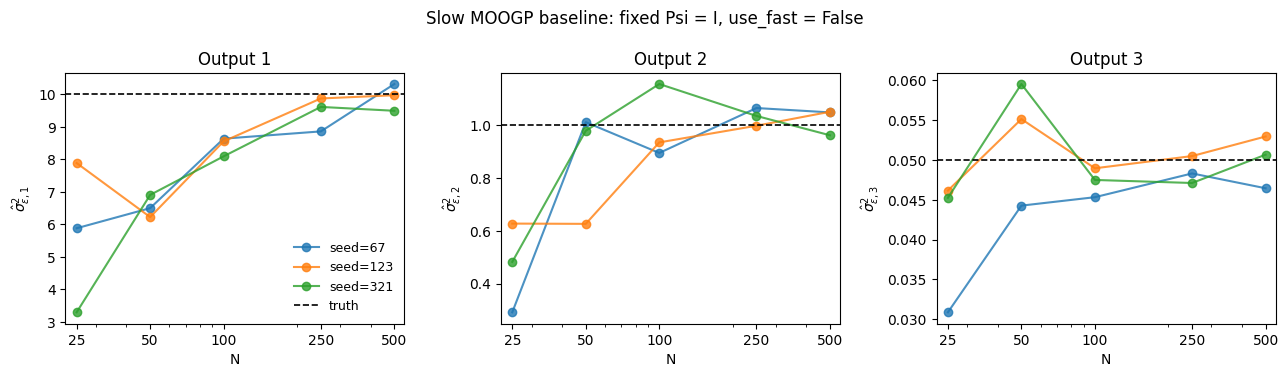

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True)

for output_idx, ax in enumerate(axes):
    for seed in seeds:
        seed_cases = sorted(
            [case for case in slow_cases if case["seed"] == seed],
            key=lambda case: case["n_train"],
        )
        ax.plot(
            [case["n_train"] for case in seed_cases],
            [case["sigma_eps2_hat"][output_idx] for case in seed_cases],
            marker="o",
            alpha=0.8,
            label=f"seed={seed}",
        )

    ax.axhline(
        diagnostic_sigma_eps2[output_idx],
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="truth" if output_idx == 0 else None,
    )
    ax.set_title(f"Output {output_idx + 1}")
    ax.set_xlabel("N")
    ylab = r"$\hat{\sigma}_{\epsilon," + str(output_idx+1) +"}^2$"
    ax.set_ylabel(ylab)
    apply_n_axis_scaling(ax, slow_sample_sizes)

axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Slow MOOGP baseline: fixed Psi = I, use_fast = False")
fig.tight_layout()


The next cell is optional but useful for diagnosis. It reruns the same study with `use_fast=True`. In the current implementation, fast mode rebuilds `Psi` from the SVD of `Y` each likelihood call, so it is not the same model as the fixed-`Psi` baseline.

In [7]:
fast_cases = run_forrester_sigma_eps_study(
    sample_sizes=fast_sample_sizes_to_run,
    seeds=seeds,
    true_sigma_eps2=diagnostic_sigma_eps2,
    Psi=None,
    use_fast=True,
    maxiter=300,
)

fast_summary = summarize_forrester_sigma_eps_study(fast_cases)
show_rows(fast_summary)


,n_train,output,true_sigma_eps2,mean_sigma_eps2_hat,std_sigma_eps2_hat,rmse_sigma_eps2_hat,used_fast
0,25,1,10.00,6.385087,1.001816,3.751164,True
1,25,2,1.00,0.513441,0.150253,0.509231,True
2,25,3,0.05,1.082436,0.126876,1.040203,True
3,50,1,10.00,6.452197,0.492082,3.581767,True
4,50,2,1.00,0.806688,0.192438,0.272768,True
5,50,3,0.05,0.534093,0.326355,0.583827,True
6,100,1,10.00,6.667339,0.582844,3.383243,True
7,100,2,1.00,1.143600,0.181942,0.231784,True
8,100,3,0.05,0.178040,0.016972,0.129160,True
9,250,1,10.00,9.111643,0.444109,0.993182,True


Fast MOOGP plotted in the same format as the slow baseline.  
The x-axis now switches to a log scale when the range of `N` gets wide, so values like `25, 50, 100, 250, 500` stay readable without bunching up the smaller sample sizes.


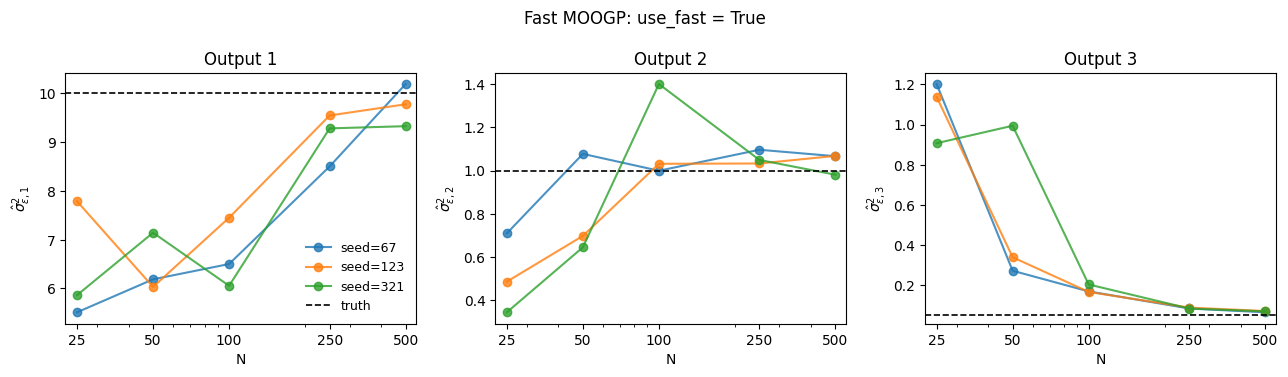

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True)

fast_sample_sizes = sorted({case["n_train"] for case in fast_cases})

for output_idx, ax in enumerate(axes):
    for seed in seeds:
        seed_cases = sorted(
            [case for case in fast_cases if case["seed"] == seed],
            key=lambda case: case["n_train"],
        )
        ax.plot(
            [case["n_train"] for case in seed_cases],
            [case["sigma_eps2_hat"][output_idx] for case in seed_cases],
            marker="o",
            alpha=0.8,
            label=f"seed={seed}",
        )

    ax.axhline(
        diagnostic_sigma_eps2[output_idx],
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="truth" if output_idx == 0 else None,
    )
    ax.set_title(f"Output {output_idx + 1}")
    ax.set_xlabel("N")
    ylab = r"$\hat{\sigma}_{\epsilon," + str(output_idx+1) +"}^2$"
    ax.set_ylabel(ylab)
    apply_n_axis_scaling(ax, fast_sample_sizes)

axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Fast MOOGP: use_fast = True")
fig.tight_layout()


In [ ]:
comparison_rows = []
shared_n_values = sorted(set(slow_sample_sizes).intersection(fast_sample_sizes_to_run))

for n_train in shared_n_values:
    slow_case = next(case for case in slow_cases if case["n_train"] == n_train and case["seed"] == 67)
    fast_case = next(case for case in fast_cases if case["n_train"] == n_train and case["seed"] == 67)
    comparison_rows.append(
        {
            "n_train": n_train,
            "slow_output3_sigma_eps2_hat": slow_case["sigma_eps2_hat"][2],
            "fast_output3_sigma_eps2_hat": fast_case["sigma_eps2_hat"][2],
            "fast_used_fast_path": fast_case["used_fast"],
        }
    )

show_rows(comparison_rows)


,n_train,slow_output3_sigma_eps2_hat,fast_output3_sigma_eps2_hat,fast_used_fast_path
0,25,0.030871,1.202186,True
1,50,0.044256,0.270461,True
2,100,0.045313,0.167434,True


Interpretation:

- If the slow baseline recovers output 3 well by `N=50` or `N=100`, then the dense implementation and the example data generation are behaving sensibly for `sigma_eps2`.
- If the fast comparison remains inflated on output 3, the discrepancy is coming from the fast `Psi = Sigma_eps^{1/2} Phi(Y)` parameterization rather than from the slow likelihood or the Forrester noise-generation step.